In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import sklearn

import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter


In [92]:
dataset = pd.read_csv('BBC News.csv')

In [93]:
dataset.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [94]:
dataset.shape

(1490, 3)

In [95]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.0+ KB


In [96]:
dataset.isna().sum()

ArticleId    0
Text         0
Category     0
dtype: int64

# NLP Tahapan 1

In [97]:
import re
from string import punctuation
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#NLTK
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

#1. Lowercase
def to_lower(text):
    return text.lower()

#2. Expand Contractions
contractions_dict = {
    "ain't": "am not", "aren't": "are not", "can't": "cannot",
    "could've": "could have", "didn't": "did not", "don't": "do not",
    "i'm": "i am", "it's": "it is", "let's": "let us", "you're": "you are",
    "won't": "will not", "wouldn't": "would not", "i've": "i have",
    "isn't": "is not", "they're": "they are", "wasn't": "was not",
    
}

def expand_contractions(text, contractions_dict):
    contractions_pattern = re.compile('({})'.format('|'.join(contractions_dict.keys())),
                                      flags=re.IGNORECASE | re.DOTALL)

    def expand_match(contraction):
        match = contraction.group(0)
        expanded = contractions_dict.get(match.lower())
        return expanded if expanded else match

    expanded_text = contractions_pattern.sub(expand_match, text)
    expanded_text = re.sub("'", "", expanded_text)
    return expanded_text

def main_contraction(text):
    return expand_contractions(text, contractions_dict)

#3. Normalize informal/slang words
custom_dict = {
    'u': 'you',
    'ur': 'your',
    'r': 'are',
    'mr': 'mister',
    'mrs': 'misses',
    'uk': 'united kingdom',
    'us': 'united states',
    'lol': 'laugh out loud',
    'idk': "i don't know",
}

def normalize_custom_words(text):
    return ' '.join([custom_dict.get(word, word) for word in text.split()])

#4. Remove numbers
def remove_numbers(text):
    return ''.join(c for c in text if not c.isdigit())

#5. Remove punctuation
def remove_punct(text):
    return ''.join(c for c in text if c not in punctuation)

#6. Remove extra whitespaces
def to_strip(text):
    return " ".join(text.split())

#7. Remove stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join([w for w in nltk.word_tokenize(text) if w not in stop_words])

#Cleaned text yang digabungkan
dataset['clean_text'] = (
    dataset['Text']
    .apply(to_lower)
    .apply(main_contraction)
    .apply(normalize_custom_words)  
    .apply(remove_numbers)
    .apply(remove_punct)
    .apply(to_strip)
    .apply(remove_stopwords)
)


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/genovevakameubun/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/genovevakameubun/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/genovevakameubun/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/genovevakameubun/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [98]:
#dataset['prep_lemmatized'] = dataset['clean_text'].apply(lemmatize_text)


In [99]:
#Preprocessing bertahap (step-by-step)
dataset['prep_lower'] = dataset['Text'].apply(to_lower)
dataset['prep_contraction'] = dataset['prep_lower'].apply(main_contraction)
dataset['prep_custom_normalized'] = dataset['prep_contraction'].apply(normalize_custom_words)  
dataset['prep_remove_numbers'] = dataset['prep_custom_normalized'].apply(remove_numbers)
dataset['prep_remove_punct'] = dataset['prep_remove_numbers'].apply(remove_punct)
dataset['prep_strip'] = dataset['prep_remove_punct'].apply(to_strip)
dataset['prep_no_stopwords'] = dataset['prep_strip'].apply(remove_stopwords)

dataset[['Text', 'prep_lower', 'prep_contraction', 'prep_remove_numbers', 'prep_remove_punct', 'prep_strip', 'prep_no_stopwords']].head()

,Text,prep_lower,prep_contraction,prep_remove_numbers,prep_remove_punct,prep_strip,prep_no_stopwords
0,worldcom ex-boss launches defence lawyers defe...,worldcom ex-boss launches defence lawyers defe...,worldcom ex-boss launches defence lawyers defe...,worldcom ex-boss launches defence lawyers defe...,worldcom exboss launches defence lawyers defen...,worldcom exboss launches defence lawyers defen...,worldcom exboss launches defence lawyers defen...
1,german business confidence slides german busin...,german business confidence slides german busin...,german business confidence slides german busin...,german business confidence slides german busin...,german business confidence slides german busin...,german business confidence slides german busin...,german business confidence slides german busin...
2,bbc poll indicates economic gloom citizens in ...,bbc poll indicates economic gloom citizens in ...,bbc poll indicates economic gloom citizens in ...,bbc poll indicates economic gloom citizens in ...,bbc poll indicates economic gloom citizens in ...,bbc poll indicates economic gloom citizens in ...,bbc poll indicates economic gloom citizens maj...
3,lifestyle governs mobile choice faster bett...,lifestyle governs mobile choice faster bett...,lifestyle governs mobile choice faster bett...,lifestyle governs mobile choice faster better ...,lifestyle governs mobile choice faster better ...,lifestyle governs mobile choice faster better ...,lifestyle governs mobile choice faster better ...
4,enron bosses in $168m payout eighteen former e...,enron bosses in $168m payout eighteen former e...,enron bosses in $168m payout eighteen former e...,enron bosses in $m payout eighteen former enro...,enron bosses in m payout eighteen former enron...,enron bosses in m payout eighteen former enron...,enron bosses payout eighteen former enron dire...


In [100]:
#Lemmatization (setelah stopwords removal)
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    return ' '.join([lemmatizer.lemmatize(word) for word in nltk.word_tokenize(text)])

dataset['prep_lemmatized'] = dataset['prep_no_stopwords'].apply(lemmatize_text)

#Cek keseluruhan
dataset[['Text', 'clean_text', 'prep_lemmatized']].head()

,Text,clean_text,prep_lemmatized
0,worldcom ex-boss launches defence lawyers defe...,worldcom exboss launches defence lawyers defen...,worldcom exboss launch defence lawyer defendin...
1,german business confidence slides german busin...,german business confidence slides german busin...,german business confidence slide german busine...
2,bbc poll indicates economic gloom citizens in ...,bbc poll indicates economic gloom citizens maj...,bbc poll indicates economic gloom citizen majo...
3,lifestyle governs mobile choice faster bett...,lifestyle governs mobile choice faster better ...,lifestyle governs mobile choice faster better ...
4,enron bosses in $168m payout eighteen former e...,enron bosses payout eighteen former enron dire...,enron boss payout eighteen former enron direct...


In [101]:
from collections import Counter

all_words = ' '.join(dataset['prep_lemmatized']).split()

word_freq = Counter(all_words)


print(word_freq.most_common(10))


[('said', 4838), ('united', 2079), ('mister', 1970), ('year', 1872), ('would', 1711), ('also', 1426), ('state', 1372), ('new', 1334), ('people', 1323), ('one', 1190)]


In [102]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Menghitung frekuensi kata
def kamus(text_series):
    text_series = text_series.str.extractall('([a-zA-Z]+)') 
    text_series.columns = ['kata']
    text_series = text_series.reset_index(drop=True)
    count = text_series['kata'].value_counts()
    
    kamus_df = pd.DataFrame({
        'kata': count.index,
        'freq': count.values
    })
    
    kamus_df.index = kamus_df['kata']
    kamus_df.drop('kata', axis=1, inplace=True)
    kamus_df.sort_values('freq', ascending=False, inplace=True)
    
    return kamus_df


In [111]:
from matplotlib import cm
import numpy as np
from matplotlib.colors import LinearSegmentedColormap



<Figure size 1000x800 with 0 Axes>

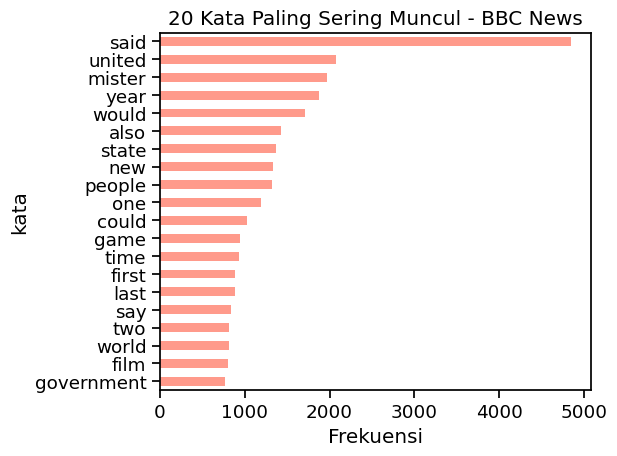

In [117]:
kamus_berita = kamus(dataset['prep_lemmatized'])
top_kata = kamus_berita[:20]
#Visualisasi
tropical_gradient = LinearSegmentedColormap.from_list("tropical_gradient", ["#ff9a8b", "#fad0c4", "#fad0c4"])
colors = tropical_gradient(np.linspace(0, 1, len(top_kata)))
sns.set_context(context='notebook', font_scale=1.2)
plt.figure(figsize=(10, 8))
top_kata.plot(kind='barh', legend=False, color=colors)
plt.title('20 Kata Paling Sering Muncul - BBC News')
plt.xlabel('Frekuensi')
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

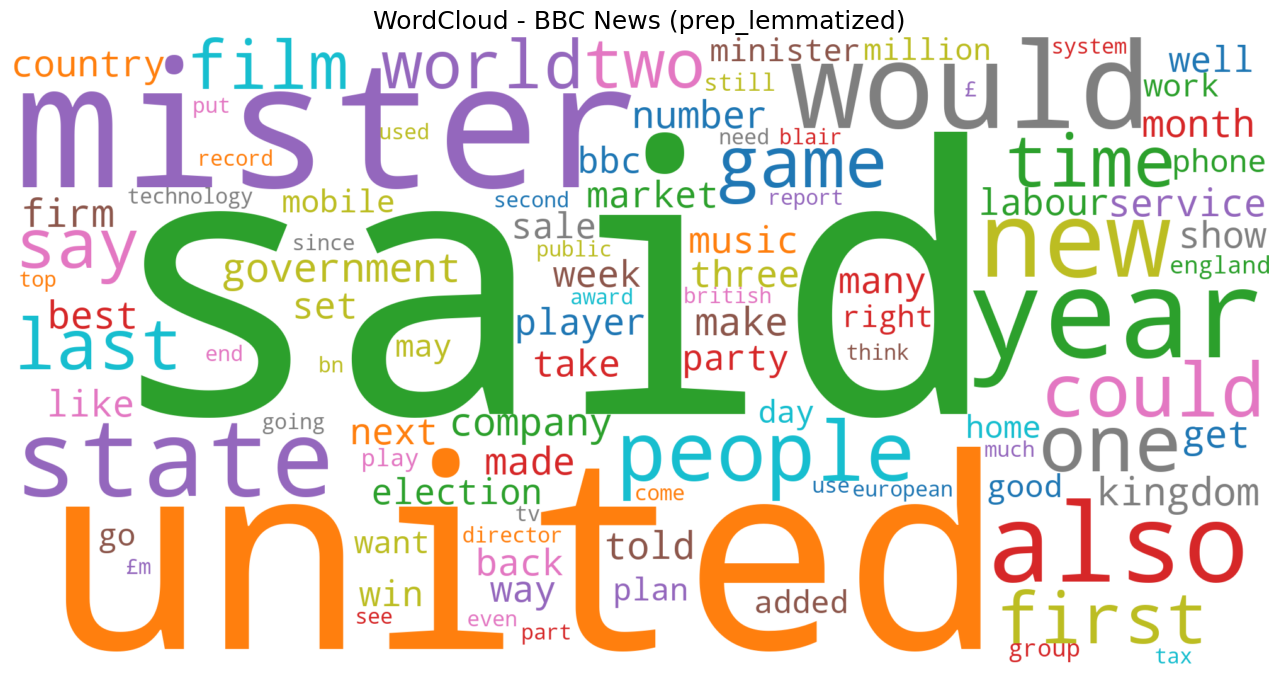

In [ ]:
#Gabungkan semua teks dan hitung frekuensi kata
all_words = ' '.join(dataset['prep_lemmatized'])
word_list = all_words.split()
word_freq = Counter(word_list)


wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white', 
    max_words=100,
    colormap='tab10',           #palet warna
    prefer_horizontal=1.0,
    scale=2,                    #resolusi tinggi
    relative_scaling=0.5        #proporsi ukuran dengan frekuensi
).generate_from_frequencies(word_freq)


plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - BBC News (prep_lemmatized)', fontsize=18)
plt.tight_layout()
plt.show()


In [121]:
dataset['categoryId'] = dataset['Category'].factorize()[0]
dataset[['Category','categoryId']].head()

,Category,categoryId
0,business,0
1,business,0
2,business,0
3,tech,1
4,business,0


In [122]:
dataset['categoryId'].duplicated().sum()

1485

In [123]:
#Lihat mapping kategori ke angka
category = dataset[["Category", "categoryId"]].drop_duplicates().sort_values('categoryId')
print("Mapping Kategori:\n", category)

Mapping Kategori:
         Category  categoryId
0       business           0
3           tech           1
5       politics           2
6          sport           3
7  entertainment           4


In [126]:
# #Visualisasi distribusi kategori
# dataset.groupby('Category').categoryId.count().plot.bar(ylim=0, color='skyblue', figsize=(10,6))
# plt.title('Distribusi Berita per Kategori')
# plt.ylabel('Jumlah Artikel')
# plt.xlabel('Kategori')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

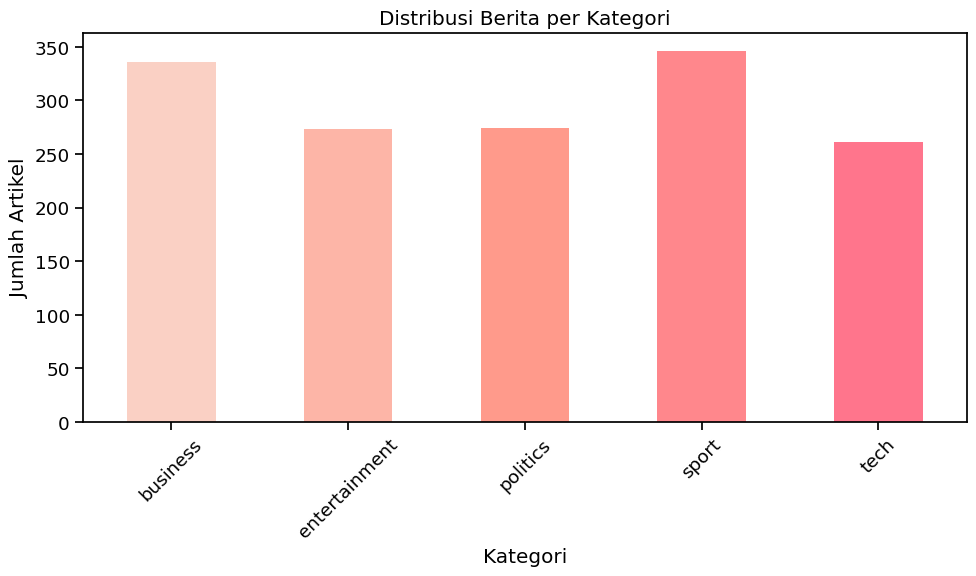

In [ ]:
tropical_colors = LinearSegmentedColormap.from_list("tropical", ["#fad0c4", "#ff9a8b", "#ff758c"])

category_counts = dataset.groupby('Category')['categoryId'].count()
colors = tropical_colors(np.linspace(0, 1, len(category_counts)))


category_counts.plot.bar(
    ylim=0,
    color=colors,
    figsize=(10, 6)
)

plt.title('Distribusi Berita per Kategori')
plt.ylabel('Jumlah Artikel')
plt.xlabel('Kategori')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Import to Bigquery

In [88]:
%pip install google-cloud-bigquery
%pip install google-auth
%pip install pandas-gbq
%pip install google-auth-oauthlib


  Obtaining dependency information for google-cloud-bigquery from https://files.pythonhosted.org/packages/e8/bc/4cb8c61fc6dd817a4a390b745ec7b305f4578f547a16d09d54c8a790624b/google_cloud_bigquery-3.31.0-py3-none-any.whl.metadata
  Obtaining dependency information for google-api-core[grpc]<3.0.0,>=2.11.1 from https://files.pythonhosted.org/packages/46/95/f472d85adab6e538da2025dfca9e976a0d125cc0af2301f190e77b76e51c/google_api_core-2.24.2-py3-none-any.whl.metadata
  Obtaining dependency information for google-auth<3.0.0,>=2.14.1 from https://files.pythonhosted.org/packages/9d/47/603554949a37bca5b7f894d51896a9c534b9eab808e2520a748e081669d0/google_auth-2.38.0-py2.py3-none-any.whl.metadata
  Obtaining dependency information for google-cloud-core<3.0.0,>=2.4.1 from https://files.pythonhosted.org/packages/40/86/bda7241a8da2d28a754aad2ba0f6776e35b67e37c36ae0c45d49370f1014/google_cloud_core-2.4.3-py2.py3-none-any.whl.metadata
  Obtaining dependency information for google-resumable-media<3.0.0,>=2

In [89]:
from google.cloud import bigquery
from google.oauth2 import service_account
from pandas.io import gbq
import pandas_gbq

In [90]:
project_id = 'iron-portfolio-456812-e2'
dataset_id = 'bbc_news'
table_name = 'BBC_News'
key_path = r"iron-portfolio-456812-e2-27eac567df5c.json"

scopes = ['https://www.googleapis.com/auth/bigquery']
credentials = service_account.Credentials.from_service_account_file(key_path, scopes=scopes)

pandas_gbq.to_gbq(dataset, 
                  f'{dataset_id}.{table_name}',
                  project_id=project_id, 
                  if_exists='replace', 
                  credentials=credentials)

100%|██████████| 1/1 [00:00<00:00, 7096.96it/s]


In [ ]:
https://console.cloud.google.com/bigquery?invt=Abuu-g&project=iron-portfolio-456812-e2&ws=!1m5!1m4!4m3!1siron-portfolio-456812-e2!2sbbc_news!3sBBC_News